In [52]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm
# %matplotlib tk

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import UNX_to_UTC
from helper import find_closest_index_dt

import math
from scipy.interpolate import interp1d

from numpy.linalg import LinAlgError

In [2]:
from detection_helper import *

In [3]:
UTC_to_UNX('2023-08-19T00:00:00')

1692403200.0

In [4]:
UTC_to_UNX('2023-08-19T00:05:00')

1692403500.0

In [5]:
UTC_to_UNX('2023-08-19T00:05:00') - UTC_to_UNX('2023-08-19T00:00:00') # UNX for 5 minutes

300.0

In [6]:
UTC_to_UNX('2023-08-19T00:03:00') - UTC_to_UNX('2023-08-19T00:00:00') # UNX for 3 minutes

180.0

In [7]:
UNX_to_UTC(300)

datetime.datetime(1970, 1, 1, 0, 5, tzinfo=datetime.timezone.utc)

In [8]:
UNX_to_UTC(300).minute

5

In [9]:
UTC_to_UNX('2023-08-19T00:03:01') - UTC_to_UNX('2023-08-19T00:03:00')

1.0

In [10]:
times_arr, freq_arr, data_arr = return_arr('2023-08-19', '2023-08-20')

24-Nov-25 23:36:35: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
24-Nov-25 23:36:35: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
24-Nov-25 23:36:35: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
24-Nov-25 23:36:35: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
24-Nov-25 23:36:35: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
24-Nov-25 23:36:36: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf
24-Nov-25 23:36:36: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
24-Nov-25 23:36:36: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf


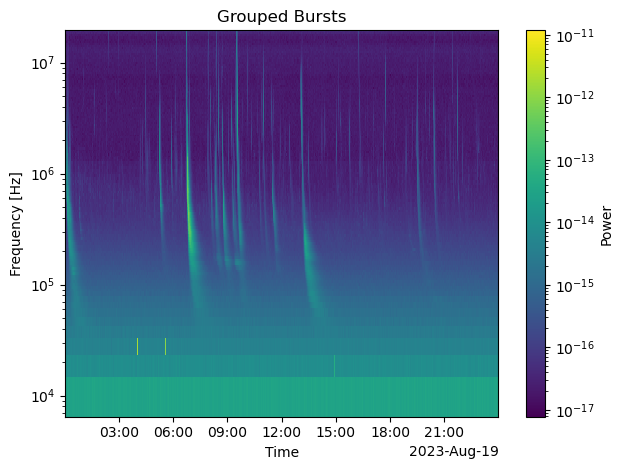

In [11]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_arr, data_arr.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
freq_log, freq_log_exp, data_arr_log = convert_data_log(freq_arr, data_arr)

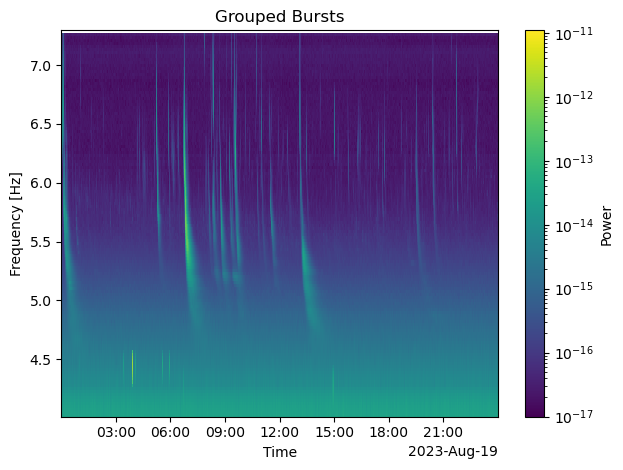

In [13]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, data_arr_log.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [14]:
data_arr_log.shape[1]

128

In [15]:
help(bmap_row_mean_loop_new)

Help on function bmap_row_mean_loop_new in module detection_helper:

bmap_row_mean_loop_new(times_arr, full_data, ratio=0.95, min_duration=60)



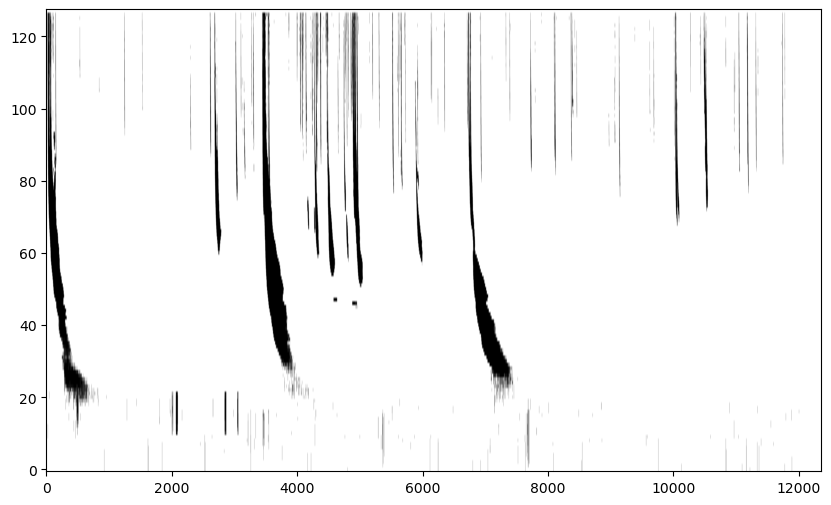

In [16]:
bmap_row_mean = bmap_row_mean_loop_new(times_arr=times_arr, full_data=data_arr_log, min_duration=1)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [17]:
threshold = 10
line_gap = 50
line_length = 100
theta=np.deg2rad(np.linspace(40, 60, 120))

threshold = 10
line_gap = 30
line_length = 110
theta=np.deg2rad(np.linspace(50, 60, 120))

threshold = 10
line_gap = 10
line_length = 120
theta=np.deg2rad(np.linspace(30, 40, 120))

lines = hough_detect(bmap_row_mean, data_arr_log, threshold, line_gap, line_length, theta)
print(lines)

[((10, 3553), (125, 3457)), ((8, 3553), (126, 3467)), ((6, 3552), (125, 3467)), ((15, 3553), (112, 3449)), ((12, 3553), (126, 3460)), ((10, 3552), (126, 3463)), ((16, 3553), (123, 3448)), ((7, 3553), (126, 3470)), ((38, 3622), (126, 3521)), ((38, 3623), (126, 3520)), ((13, 3546), (125, 3448)), ((40, 3604), (125, 3504)), ((39, 3615), (126, 3515)), ((36, 3645), (126, 3545)), ((9, 3553), (126, 3478)), ((36, 3637), (126, 3536)), ((37, 3632), (126, 3530)), ((18, 4577), (120, 4459)), ((11, 3553), (114, 3485)), ((43, 3589), (126, 3489)), ((41, 3600), (126, 3499)), ((14, 3553), (102, 3451)), ((36, 3638), (126, 3537)), ((17, 4576), (120, 4460)), ((39, 3618), (126, 3514)), ((15, 3675), (118, 3555)), ((36, 3643), (125, 3543)), ((9, 5004), (126, 4927)), ((6, 3553), (125, 3479)), ((37, 3640), (124, 3537)), ((9, 5005), (126, 4892)), ((36, 3649), (125, 3544)), ((38, 3620), (126, 3517)), ((14, 3547), (117, 3449)), ((37, 222), (125, 119)), ((38, 219), (126, 114)), ((17, 4577), (126, 4460)), ((38, 3621)

In [18]:
first_line = lines[0]
first_line

((10, 3553), (125, 3457))

In [19]:
times_arr[first_line[1][1]]

numpy.datetime64('2023-08-19T06:42:53.058211584')

In [20]:
time_diff = 300
freq_diff = 10000

time_diff = 1000
freq_diff = 100000000

line_sets, line_sets_actual = line_grouping_new(times_arr, freq_log, lines, time_diff, freq_diff)
line_sets_actual

[(('2023-08-19 00:12:27.818819+00:00', 16057123.76350689),
  ('2023-08-19 00:24:13.861621+00:00', 105702.55661457374)),
 (('2023-08-19 06:41:50.143653+00:00', 15135685.013465311),
  ('2023-08-19 06:54:04.148373+00:00', 27150.322768154856)),
 (('2023-08-19 08:39:37.560934+00:00', 12676666.35635252),
  ('2023-08-19 08:53:22.442617+00:00', 30556.692535528306)),
 (('2023-08-19 09:30:04.457019+00:00', 18071703.899664175),
  ('2023-08-19 09:43:14.386061+00:00', 17952.10092489592)),
 (('2023-08-19 13:27:45.123626+00:00', 4375452.099588066),
  ('2023-08-19 13:41:02.043392+00:00', 11870.132461027475))]

In [21]:
freq_gap, times_gap = find_unit(freq_log_exp, times_arr)
freq_gap, times_gap

(0.025665673683947787, 6.990724086761475)

In [22]:
freq_log[1]

11188.964390156958

In [23]:
freq_log[0]

10546.885178850274

In [24]:
freq_log[1] - freq_log[0]

642.0792113066836

In [25]:
freq_log[2] - freq_log[1]

681.1680708705171

In [26]:
freq_log[3] - freq_log[2]

722.6366040246612

In [27]:
freq_log_exp

array([4.02312422, 4.04878989, 4.07445557, 4.10012124, 4.12578691,
       4.15145259, 4.17711826, 4.20278393, 4.22844961, 4.25411528,
       4.27978095, 4.30544663, 4.3311123 , 4.35677798, 4.38244365,
       4.40810932, 4.433775  , 4.45944067, 4.48510634, 4.51077202,
       4.53643769, 4.56210337, 4.58776904, 4.61343471, 4.63910039,
       4.66476606, 4.69043173, 4.71609741, 4.74176308, 4.76742875,
       4.79309443, 4.8187601 , 4.84442578, 4.87009145, 4.89575712,
       4.9214228 , 4.94708847, 4.97275414, 4.99841982, 5.02408549,
       5.04975117, 5.07541684, 5.10108251, 5.12674819, 5.15241386,
       5.17807953, 5.20374521, 5.22941088, 5.25507655, 5.28074223,
       5.3064079 , 5.33207358, 5.35773925, 5.38340492, 5.4090706 ,
       5.43473627, 5.46040194, 5.48606762, 5.51173329, 5.53739897,
       5.56306464, 5.58873031, 5.61439599, 5.64006166, 5.66572733,
       5.69139301, 5.71705868, 5.74272435, 5.76839003, 5.7940557 ,
       5.81972138, 5.84538705, 5.87105272, 5.8967184 , 5.92238

In [28]:
freq_log_exp[1] - freq_log_exp[0]

0.025665673683947787

<Figure size 1000x600 with 0 Axes>

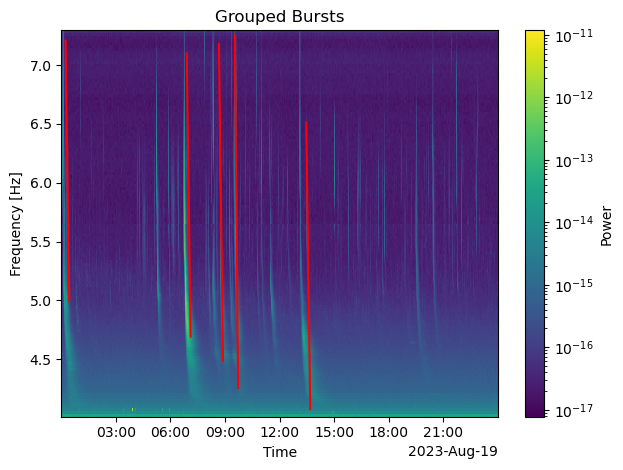

In [29]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0], times_arr[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
lines = hough_detect(bmap_row_mean, data_arr_log, threshold=10, line_gap=50, line_length=60, theta=np.deg2rad(np.linspace(40, 60, 120)))
line_sets, line_sets_actual = line_grouping_new(times_arr, freq_log, lines, time_diff, freq_diff)
line_sets_actual

[(('2023-08-19 00:12:27.818819+00:00', 15135685.013465311),
  ('2023-08-19 00:24:06.871142+00:00', 105702.55661457374)),
 (('2023-08-19 06:41:50.143653+00:00', 15135685.013465311),
  ('2023-08-19 06:54:04.148373+00:00', 19044.99902776607)),
 (('2023-08-19 08:39:44.551658+00:00', 12676666.35635252),
  ('2023-08-19 08:53:15.452138+00:00', 28803.19539681081)),
 (('2023-08-19 09:29:57.466540+00:00', 18071703.899664175),
  ('2023-08-19 09:43:14.386061+00:00', 17952.10092489592)),
 (('2023-08-19 13:27:45.123626+00:00', 4375452.099588066),
  ('2023-08-19 13:41:09.033871+00:00', 10546.885178850274))]

<Figure size 1000x600 with 0 Axes>

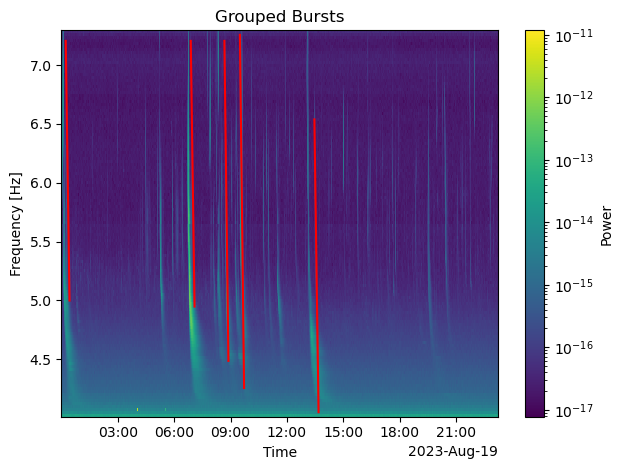

In [31]:
plt.figure(figsize=(10, 6))

fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr[:-400], freq_log_exp, data_arr.T[:, :-400], norm=LogNorm())
plt.colorbar(p, label='Power')

for (x0, y0), (x1, y1) in line_sets:
    t0, t1 = times_arr[y0], times_arr[y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

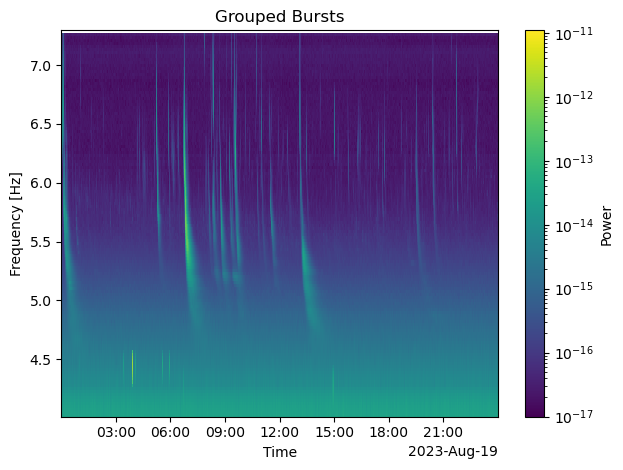

In [34]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, img.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

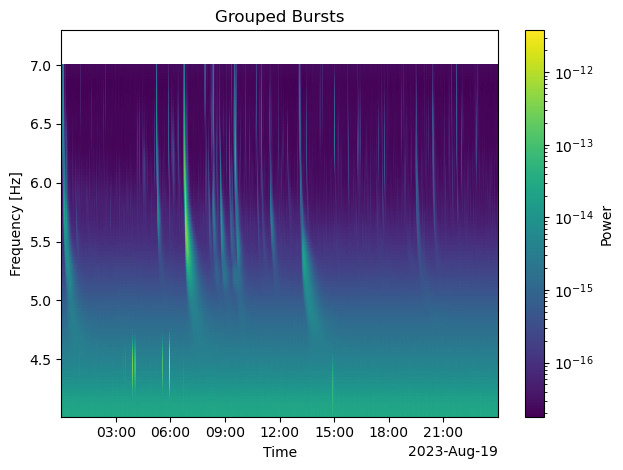

In [35]:
blurred = gaussian_filter(img, sigma=2.5)
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, blurred.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()